# Section 17: Running models on a GPU

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from torch.nn import functional as F
import torch

## Implementation

In [2]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

print(device)

mps


In [3]:
net = nn.Sequential(
    nn.Linear(20, 100),
    nn.ReLU(),
    nn.Linear(100, 500),
    nn.ReLU(),
    nn.Linear(500, 30),
    nn.ReLU(),
    nn.Linear(30, 2)
)

In [4]:
data = torch.randn((1000, 20))
labels = torch.randint(low=0, high=2, size=(1, 1000))

In [5]:
net.to(device)

data = data.to(device)
labels = labels.to(device)

In [6]:
data

tensor([[-1.0999,  0.5809,  1.5548,  ..., -0.7909, -0.4673, -0.4046],
        [ 0.8105,  2.1485,  0.5350,  ...,  0.6662,  1.1740,  0.6104],
        [-0.4121,  0.4446, -0.0937,  ...,  1.0830,  1.9748, -0.6591],
        ...,
        [-0.3164, -2.6283, -0.4764,  ..., -0.6211, -0.3409,  1.1905],
        [-0.2787,  0.4722, -1.2046,  ...,  0.3168, -1.1647,  2.0497],
        [-1.1203,  0.9731,  0.6067,  ..., -1.2383,  0.8935, -0.1489]],
       device='mps:0')

In [7]:
data_mps = torch.randn((1000, 20), device=device)
data_cpu = torch.randn((1000, 20), device='cpu')

print(data.device)
print(data_mps.device)
print(data_cpu.device)

mps:0
mps:0
cpu


In [8]:
output = net(data)

output.device

device(type='mps', index=0)

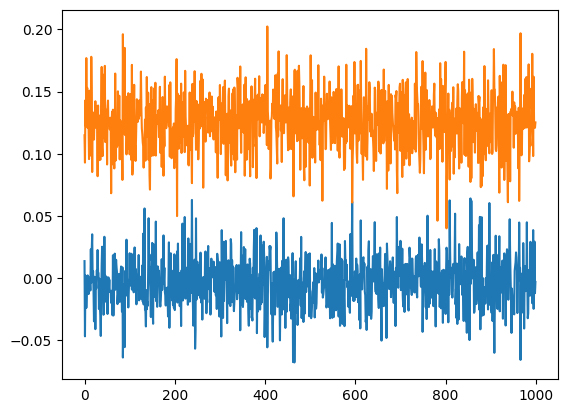

In [9]:
plt.plot(output.detach().cpu())
plt.show()

## CodeChallenge: Run an experiment on the GPU

In [10]:
data = np.loadtxt(open('mnist_train_small.csv', 'rb'), delimiter=',')
X = data[:, 1:]
y = data[:, 0]
X_norm = X / np.max(X)

X_tensor = torch.tensor(X_norm).float().to(device)
y_tensor = torch.tensor(y).long().to(device)

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=.1)

X_y_train = TensorDataset(X_train, y_train)
X_y_test = TensorDataset(X_test, y_test)

batch_size = 256
train_loader = DataLoader(X_y_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(X_y_test, batch_size=X_y_test.tensors[0].shape[0])

In [11]:
def create_model(units_param, layers_param):
    class AnnMnist(nn.Module):
        def __init__(self, units_model_param, layers_model_param):
            super().__init__()
            
            self.layers = nn.ModuleDict()
            self.layers_nr = layers_model_param
            self.layers['input'] = nn.Linear(784, units_model_param)
            
            for layer_model in range(layers_model_param):
                self.layers[f'hidden_{layer_model}'] = nn.Linear(units_model_param, units_model_param)
                
            self.layers['output'] = nn.Linear(units_model_param, 10)
            
        def forward(self, x_param):
            x_local = F.relu(self.layers['input'](x_param))
            
            for layer_nr in range(self.layers_nr):
                x_local = F.relu(self.layers[f'hidden_{layer_nr}'](x_local))
                
            x_local = self.layers['output'](x_local)
            x_local = torch.log_softmax(x_local, axis=1)
            
            return x_local
    
    ann_mnist_local = AnnMnist(units_param, layers_param).to(device)
    loss_function_local = nn.NLLLoss()
    optimizer_local = torch.optim.SGD(ann_mnist_local.parameters(), lr=.01)
    
    return ann_mnist_local, loss_function_local, optimizer_local

In [12]:
def train_model(model_param, loss_fun_param, optimizer_param, epochs_param):    
    train_accuracies_local = []
    test_accuracies_local = []
    losses_local = []
     
    for epoch in range(epochs_param):
        batch_accuracies = []
        batch_losses = []
         
        model_param.train()
         
        for X_local, y_local in train_loader:
            y_pred = model_param(X_local)
            loss = loss_fun_param(y_pred, y_local)
               
            optimizer_param.zero_grad()
            loss.backward()
            optimizer_param.step()
               
            correct_predictions = (torch.argmax(y_pred, axis=1) == y_local).float()
             
            batch_accuracies.append(100 * torch.mean(correct_predictions).item())
            batch_losses.append(loss.item())

        train_accuracies_local.append(np.mean(batch_accuracies))
        losses_local.append(np.mean(batch_losses))
    
        model_param.eval()
          
        X_local, y_local = next(iter(test_loader))
          
        with torch.no_grad():
            y_pred = model_param(X_local)
          
        correct_predictions = (torch.argmax(y_pred, axis=1) == y_local).float()
          
        test_accuracies_local.append(100 * torch.mean(correct_predictions).item())
     
    return train_accuracies_local, test_accuracies_local, losses_local

In [13]:
units = np.arange(50, 251, 50)
layers = [1, 2, 3]   
accuracies  = np.zeros((2, len(units), len(layers)))
epochs = 60

for unit_i, unit in enumerate(units):
    for layer_j, layer in enumerate(layers):
        ann_mnist, loss_function, optimizer = create_model(unit, layer)
        train_accuracies, test_accuracies, _ = train_model(ann_mnist, loss_function, optimizer, epochs)
        accuracies[0, unit_i, layer_j] = np.mean(train_accuracies[-5:])
        accuracies[1, unit_i, layer_j] = np.mean(test_accuracies[-5:])
        
        print(f"Finished units {unit_i + 1}/{len(units)} and layers {layer_j + 1}/{len(layers)}") 

Finished units 1/5 and layers 1/3
Finished units 1/5 and layers 2/3
Finished units 1/5 and layers 3/3
Finished units 2/5 and layers 1/3
Finished units 2/5 and layers 2/3
Finished units 2/5 and layers 3/3
Finished units 3/5 and layers 1/3
Finished units 3/5 and layers 2/3
Finished units 3/5 and layers 3/3
Finished units 4/5 and layers 1/3
Finished units 4/5 and layers 2/3
Finished units 4/5 and layers 3/3
Finished units 5/5 and layers 1/3
Finished units 5/5 and layers 2/3
Finished units 5/5 and layers 3/3
